
# Notebook Overview

This Jupyter Notebook is designed to generate the high imbalanced and equally balanced variations for all the datasets to be analyzed in the thesis.

## Key Components

### Datasets Information
The notebook works with 11 datasets, each with specific attributes:
- **`dataset_names`**: Names of the datasets.
- **`dataset_files`**: File paths for the datasets.
- **`dataset_targets`**: Target columns for prediction.
- **`dataset_attr_mappings`**: Mappings for protected attributes (e.g., gender, race). Note that 1 will always be the privileged group.


In [1]:
dataset_names = ["Predict Students' Dropout and Academic Success",
                 "Employee dataset",
                 "COMPAS",
                 "Adult",
                 "Bank Marketing",
                 "Heart Dataset",
                 "Indian Liver Patient Dataset",
                 "AIDS Clinical Trials Group Study 175",
                 "Intersectional Bias Dataset",
                 "Diabetes",
                 "Glioma"]


dataset_files = [
    "datasets/dropout_converted.csv",
    "datasets/Employee_converted.csv",
    "datasets/compas-scores-raw_converted.csv",
    "datasets/adult_converted.csv",
    "datasets/bank-full_converted.csv",
    "datasets/heart_converted.csv",
    "datasets/indian_converted.csv",
    "datasets/AIDS_ClinicalTrial_GroupStudy175_converted.csv",
    "datasets/intersectional-bias_converted.csv",
    "datasets/diabetes_binary_health_indicators_BRFSS2015_converted.csv",
    "datasets/Glioma_converted.csv"]

dataset_targets = [
    "Target",
    "LeaveOrNot",
    "is_recid",
    "income",
    "y",
    "target",
    "Target",
    "label",
    "Diagnosis",
    "Diabetes_binary",
    "Grade"
]

dataset_attr_mappings = [
    {"Gender": {"Female": 0, "Male": 1}},
    {"Gender": {"Female": 0, "Male": 1}},
    {"sex": {"Female": 0, "Male": 1}},
    {"sex": {"Female": 0, "Male": 1}},
    {"marital": {"not married": 0, "married": 1}},
    {"sex": {"Female": 0, "Male": 1}},
    {"Sex": {"Female": 0, "Male": 1}},
    {"homo": {"Yes": 0, "No": 1}},
    {"Sex": {"Female": 0, "Male": 1}},
    {"Sex": {"Female": 0, "Male": 1}},
    {"Race": {"Non-White": 0, "White": 1}}
]

Import all needed libraries (and reload the farinessinsight to catch any changes)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import fairnessinsight
import os
importlib.reload(fairnessinsight)
from fairnessinsight.Datasets.BaseDataset import BaseDataset
import json

Create the results folder (if not exists)

In [3]:
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

## Highly Unbalanced Variations
In this variation, we try to maximize the metrics values. We remove from 0 to 95% of instances in the unprivileged group with favorable outcome OR privileged group with unfavorable outcome. We calculate the metrics from this new dataset.

A plot is generated with the metrics values from each iteration, and in the end the percentage that maximized most of the metrics is used to create a new dataset (saved under `results/<dataset_name>/high_imbalance/<dataset_name>_imbalanced_dataset`). Two JSON files are generated in this step, one with the percentage removed and the metrics values (the one used to generate the plots) and one with the maximum percentage for each metric.

In [4]:
for name, file, target, attr_mapping in zip(
    dataset_names, dataset_files, dataset_targets, dataset_attr_mappings
):
    print(f"Processing dataset: {name}")
    df = pd.read_csv(file)
    
    bd = BaseDataset()
    bd.predicted_attr = target
    bd.random_state = 0
    bd.positive_outcome = 1
    bd.protected_attr_mappings = attr_mapping
    
    # Experiment: Remove percentages of the protected group
    percentages = np.arange(0, 10, 0.5) / 10
    results = []
    np.random.seed(bd.random_state)
    
    for pct in percentages:
        df_var = df.copy()
        protected_attr =  list(attr_mapping.keys())[0]
        protected_value = 0
        
        # changed to remove from both protected and unprotected groups
        protected_idx = df.loc[
            ((df[protected_attr] == protected_value) & (df[target] == 1)) |
            ((df[protected_attr] != protected_value) & (df[target] != 1))
        ].index
        n_remove = int(len(protected_idx) * pct)
        if n_remove > 0:
            idx_remove = np.random.choice(protected_idx, n_remove, replace=False)
            df_var = df_var.drop(idx_remove)
        
        # Evaluate metrics
        metrics = bd.evaluate_pre_training_metrics(protected_attr, 1, df_var, False)
        results.append({
            "percentage_removed": pct,
            "metrics": metrics,
        })
    
    # Plot results
    percentages = [r['percentage_removed'] * 100 for r in results]
    metrics_names = list(results[0]['metrics'].keys())
    metrics_data = {name: [r['metrics'][name] for r in results] for name in metrics_names}
    
    # Save the plot
    dataset_output_dir = os.path.join(output_dir, f"{name.replace(' ', '_')}/high_imbalance")
    os.makedirs(dataset_output_dir, exist_ok=True)

    json.dump(results, open(os.path.join(dataset_output_dir, f"{name.replace(' ', '_')}_high_imbalance_results.json"), "w"), indent=4)
    max_metrics = {}

    plt.figure(figsize=(10, 6))
    for metric_name in metrics_names:
        plt.plot(percentages, metrics_data[metric_name], marker='o', label=metric_name)
        max_value = max(metrics_data[metric_name])
        max_index = metrics_data[metric_name].index(max_value)
        max_percentage = percentages[max_index]
        
        plt.text(
            max_percentage, max_value, 
            f'{max_value:.2f}', 
            fontsize=9, 
            ha='center', 
            va='bottom', 
            color='black'
        )
        metric_values = [r['metrics'][metric_name] for r in results]
    
        # Find the maximum value and its corresponding percentage
        max_value = max(metric_values)
        max_index = metric_values.index(max_value)
        max_percentage = results[max_index]['percentage_removed'] * 100  # Convert to percentage
        
        # Store the result
        max_metrics[metric_name] = {
            "max_value": max_value,
            "max_percentage": max_percentage
        }
    # get the percentage that appears the most as max
    percentages_max = [v['max_percentage'] for v in max_metrics.values()]
    most_common_percentage = max(set(percentages_max), key=percentages_max.count)
    print(f"Most common max percentage for {name}: {most_common_percentage}%")
    
    plt.xlabel('Percentage of Protected Group Removed (%)')
    plt.ylabel('Metric Value')
    plt.title(f'Fairness Metrics vs. Percentage Removed ({name})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    plt.savefig(os.path.join(dataset_output_dir, "fairness_metrics.png"))
    plt.close()

    # save the dataset
    most_common_pct = most_common_percentage / 100
    df_var = df.copy()
    protected_idx = df.loc[
        ((df[protected_attr] == protected_value) & (df[target] == bd.positive_outcome)) |
        ((df[protected_attr] != protected_value) & (df[target] != bd.positive_outcome))
    ].index
    n_remove = int(len(protected_idx) * most_common_pct)
    if n_remove > 0:
        idx_remove = np.random.choice(protected_idx, n_remove, replace=False)
        df_var = df_var.drop(idx_remove)

    # Save the dataset")
    df_var.to_csv(os.path.join(dataset_output_dir, f"{name.replace(' ', '_')}_imbalanced_dataset.csv"), index=False)
    
    json.dump(max_metrics, open(os.path.join(dataset_output_dir, "max_metrics.json"), "w"), indent=4)
    

Processing dataset: Predict Students' Dropout and Academic Success
Most common max percentage for Predict Students' Dropout and Academic Success: 95.0%
Processing dataset: Employee dataset
Most common max percentage for Employee dataset: 95.0%
Processing dataset: COMPAS
Most common max percentage for COMPAS: 95.0%
Processing dataset: Adult
Most common max percentage for Adult: 95.0%
Processing dataset: Bank Marketing
Most common max percentage for Bank Marketing: 95.0%
Processing dataset: Heart Dataset
Most common max percentage for Heart Dataset: 95.0%
Processing dataset: Indian Liver Patient Dataset
Most common max percentage for Indian Liver Patient Dataset: 95.0%
Processing dataset: AIDS Clinical Trials Group Study 175
Most common max percentage for AIDS Clinical Trials Group Study 175: 95.0%
Processing dataset: Intersectional Bias Dataset
Most common max percentage for Intersectional Bias Dataset: 95.0%
Processing dataset: Diabetes
Most common max percentage for Diabetes: 95.0%
Pr

## Generating equal balanced configurations
- For each dataset:
    - Check number of instances in each cohort, protected attribute + outcome combinations
    - Get the minimum for each cohort and select from the other to make the same distribution

The new dataset is saved under `results/<dataset_name>/equal_balance/<dataset_name>_balanced_dataset.csv`


In [5]:
for name, file, target, attr_mapping in zip(
    dataset_names, dataset_files, dataset_targets, dataset_attr_mappings
):
    print(f"Processing dataset: {name}")
    df = pd.read_csv(file)
    
    bd = BaseDataset()
    bd.predicted_attr = target
    bd.random_state = 0
    bd.positive_outcome = 1
    bd.protected_attr_mappings = attr_mapping
    
    np.random.seed(bd.random_state)
    
    # Extract the protected attribute
    protected_attr = list(attr_mapping.keys())[0]
    
    # Count instances in each cohort
    unprivileged_favorable = df.loc[(df[protected_attr] == 0) & (df[target] == 1)]
    unprivileged_unfavorable = df.loc[(df[protected_attr] == 0) & (df[target] != 1)]
    privileged_favorable = df.loc[(df[protected_attr] != 0) & (df[target] == 1)]
    privileged_unfavorable = df.loc[(df[protected_attr] != 0) & (df[target] != 1)]
    
    # Find the minimum count across all cohorts
    min_count = min(
        len(unprivileged_favorable),
        len(unprivileged_unfavorable),
        len(privileged_favorable),
        len(privileged_unfavorable)
    )
    
    # Sample from each cohort to match the minimum count
    balanced_unprivileged_favorable = unprivileged_favorable.sample(min_count, random_state=bd.random_state)
    balanced_unprivileged_unfavorable = unprivileged_unfavorable.sample(min_count, random_state=bd.random_state)
    balanced_privileged_favorable = privileged_favorable.sample(min_count, random_state=bd.random_state)
    balanced_privileged_unfavorable = privileged_unfavorable.sample(min_count, random_state=bd.random_state)
    
    # Combine the balanced cohorts into a new DataFrame
    balanced_df = pd.concat([
        balanced_unprivileged_favorable,
        balanced_unprivileged_unfavorable,
        balanced_privileged_favorable,
        balanced_privileged_unfavorable
    ])
    
    # Shuffle the balanced dataset
    balanced_df = balanced_df.sample(frac=1, random_state=bd.random_state).reset_index(drop=True)
    
    # Evaluate metrics on the balanced dataset
    metrics = bd.evaluate_pre_training_metrics(protected_attr, 1, balanced_df, False)
    
    # Save the balanced dataset and metrics
    dataset_output_dir = os.path.join(output_dir, f"{name.replace(' ', '_')}/equal_balance")
    os.makedirs(dataset_output_dir, exist_ok=True)
    
    balanced_df.to_csv(os.path.join(dataset_output_dir, f"{name.replace(' ', '_')}_balanced_dataset.csv"), index=False)
    json.dump(metrics, open(os.path.join(dataset_output_dir, "metrics.json"), "w"), indent=4)
    

Processing dataset: Predict Students' Dropout and Academic Success
Processing dataset: Employee dataset
Processing dataset: COMPAS
Processing dataset: Adult
Processing dataset: Bank Marketing
Processing dataset: Heart Dataset
Processing dataset: Indian Liver Patient Dataset
Processing dataset: AIDS Clinical Trials Group Study 175
Processing dataset: Intersectional Bias Dataset
Processing dataset: Diabetes
Processing dataset: Glioma


The cell below processes each dataset to generate a distribution comparison plot for three variations of the dataset:
1. **Original Dataset**: The dataset as it was initially loaded.
2. **High Imbalanced Dataset**: A version of the dataset where a percentage of the protected group has been removed to simulate imbalance.
3. **Equal Balanced Dataset**: A version of the dataset where the distribution of protected attribute and outcome combinations is balanced.

#### Key Steps:
- **Dataset Loading**: The original, high imbalanced, and equal balanced datasets are loaded from their respective file paths.
- **Protected Attribute Identification**: The protected attribute for each dataset is identified using the `dataset_attr_mappings`.
- **Distribution Calculation**: The counts of each combination of the protected attribute and the target variable are calculated for all three dataset variations.
- **Plotting**: A side-by-side bar plot is created to visualize the distribution of the protected attribute and target variable combinations for the three dataset variations.
- **Saving the Plot**: The generated plot is saved as an image file in the corresponding dataset's output directory.

This visualization helps to understand how the distribution of the protected attribute and target variable changes across the original, high imbalanced, and equal balanced datasets.


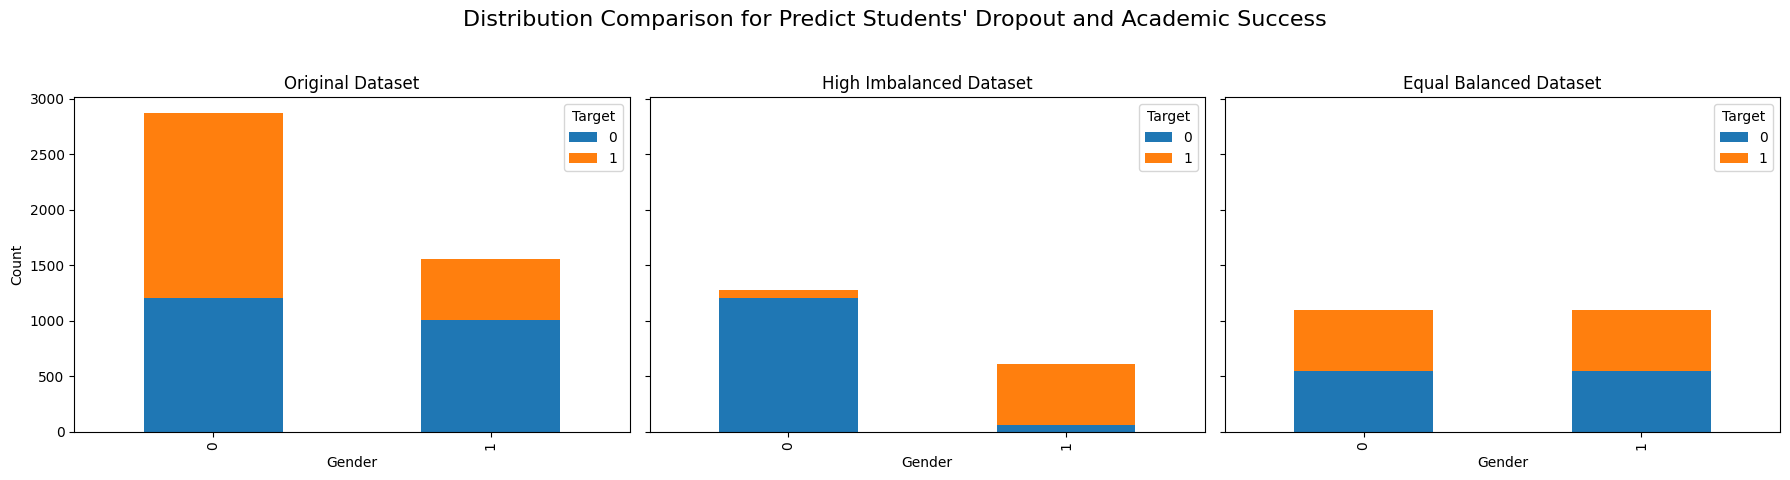

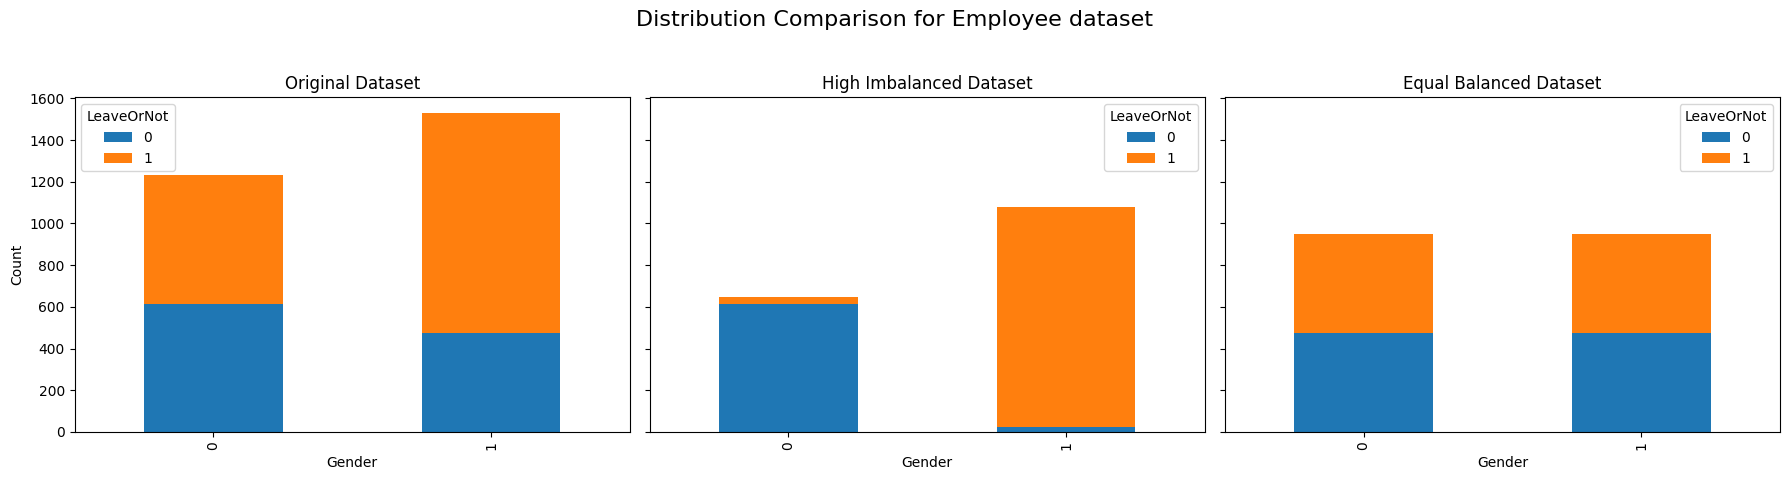

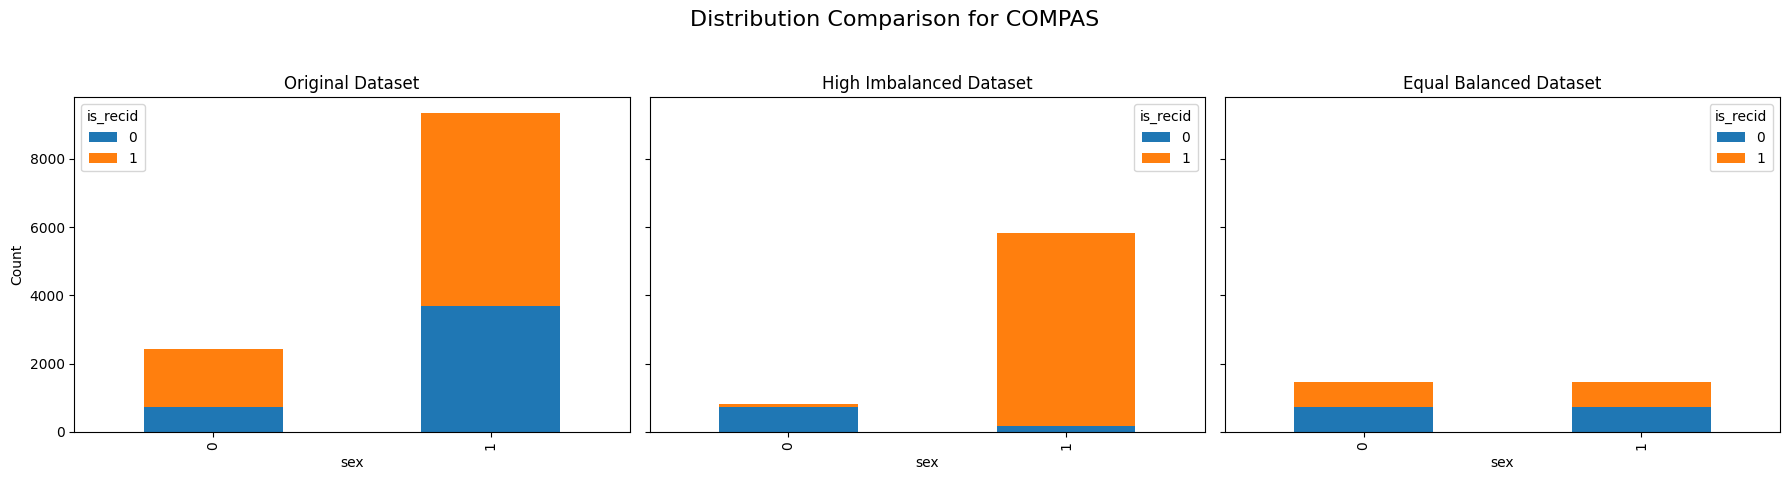

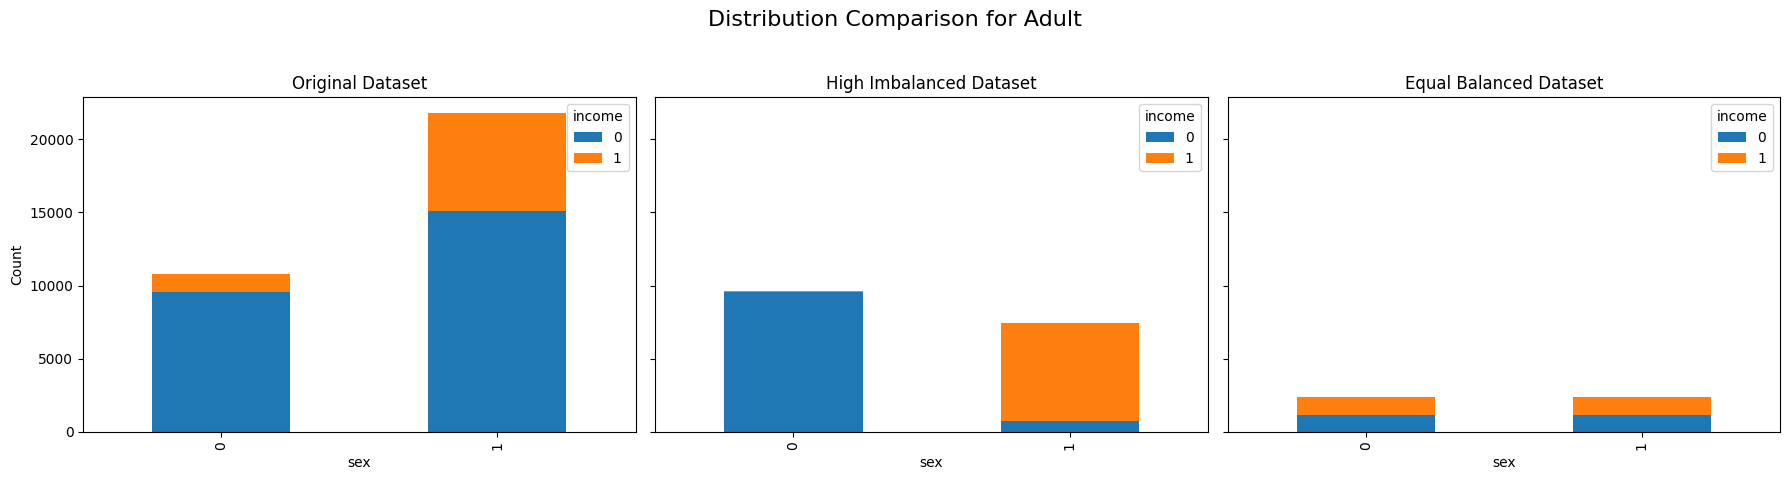

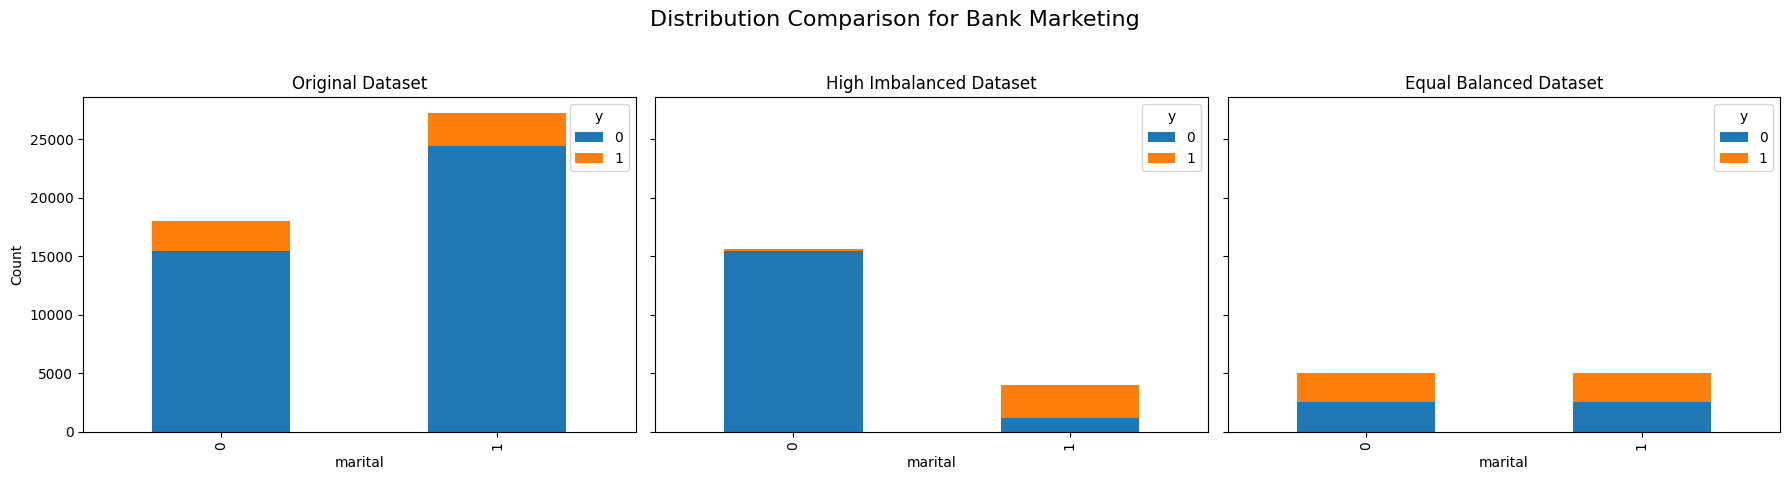

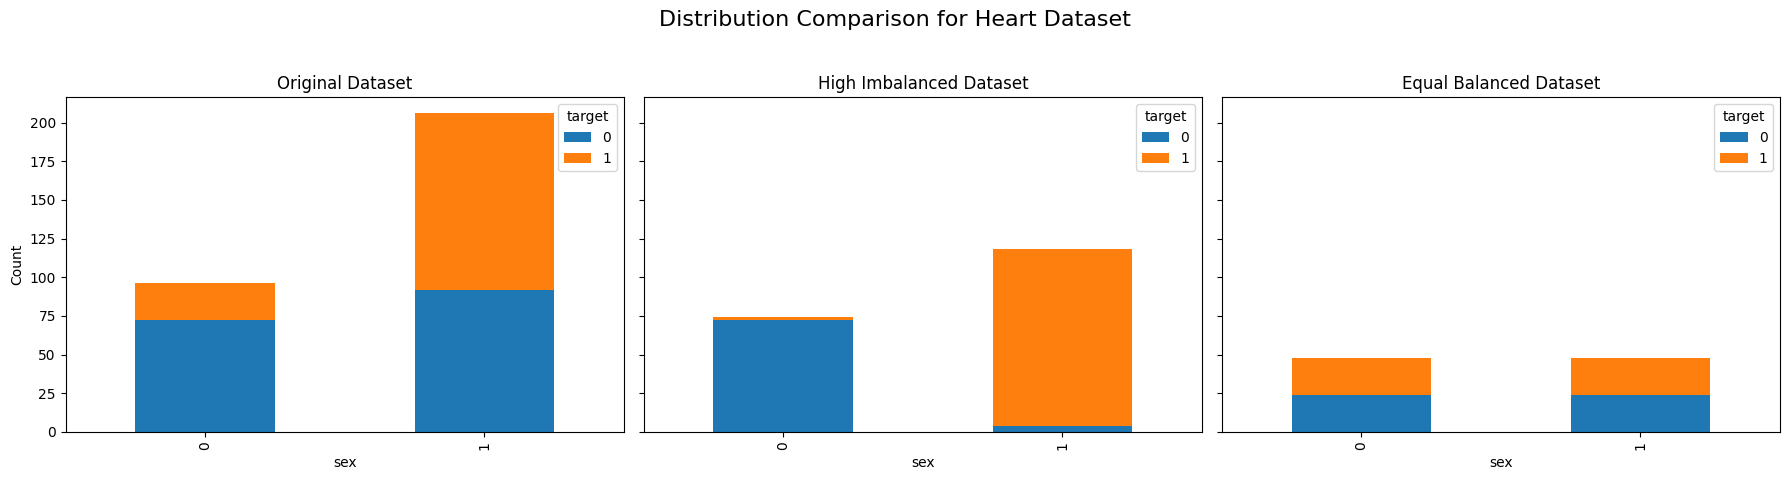

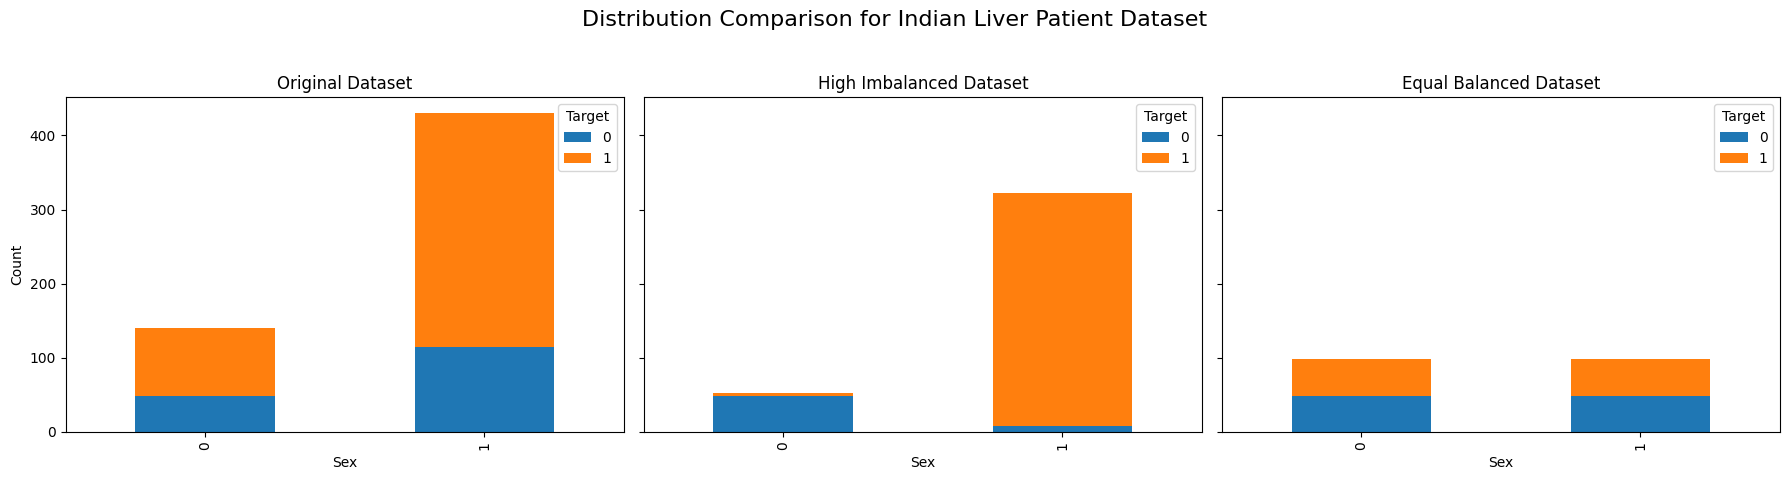

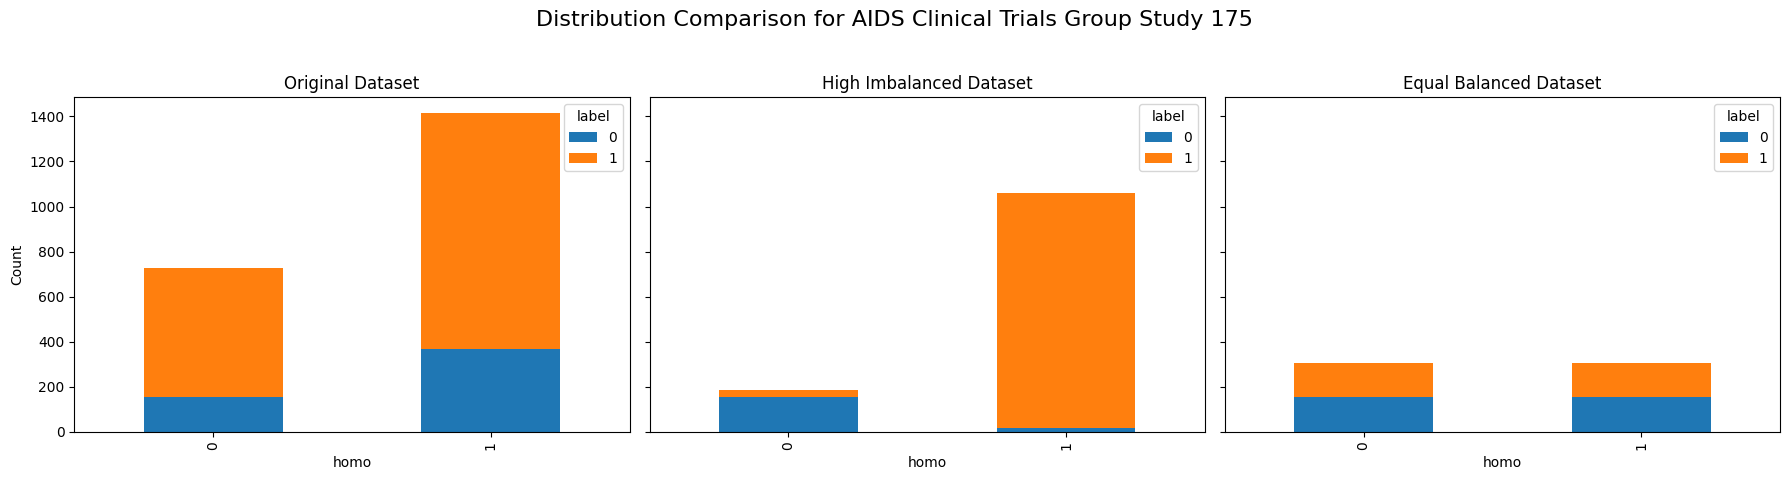

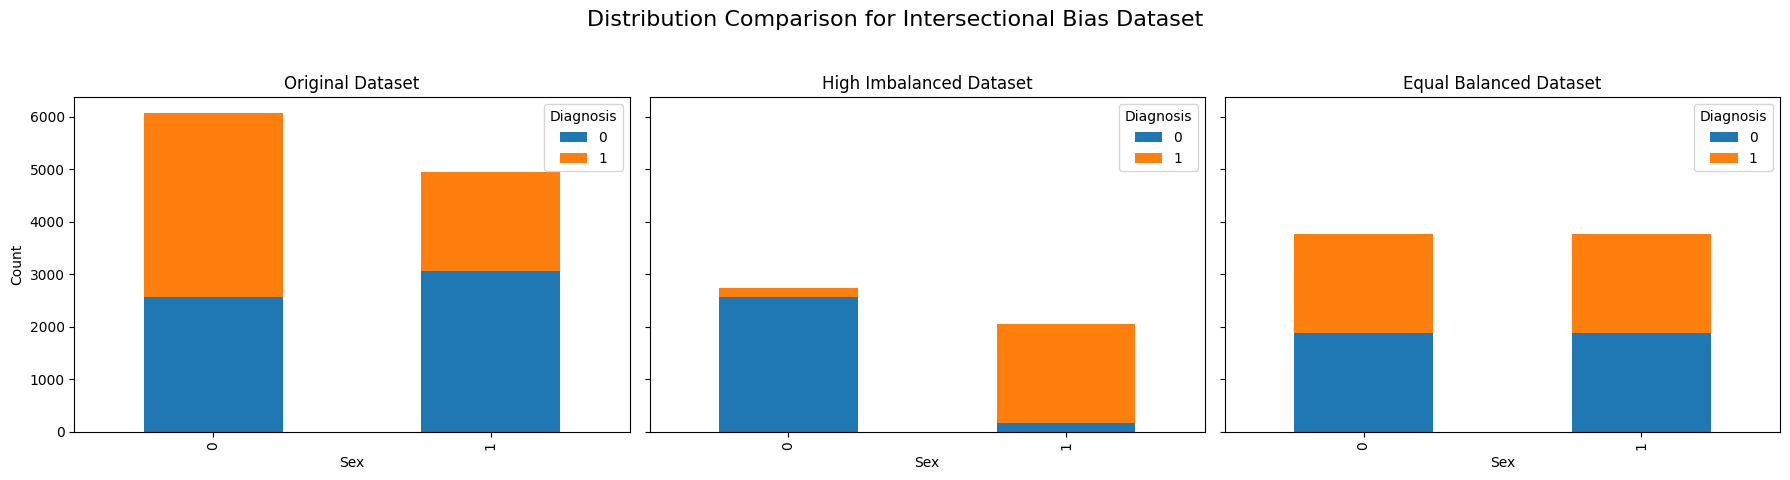

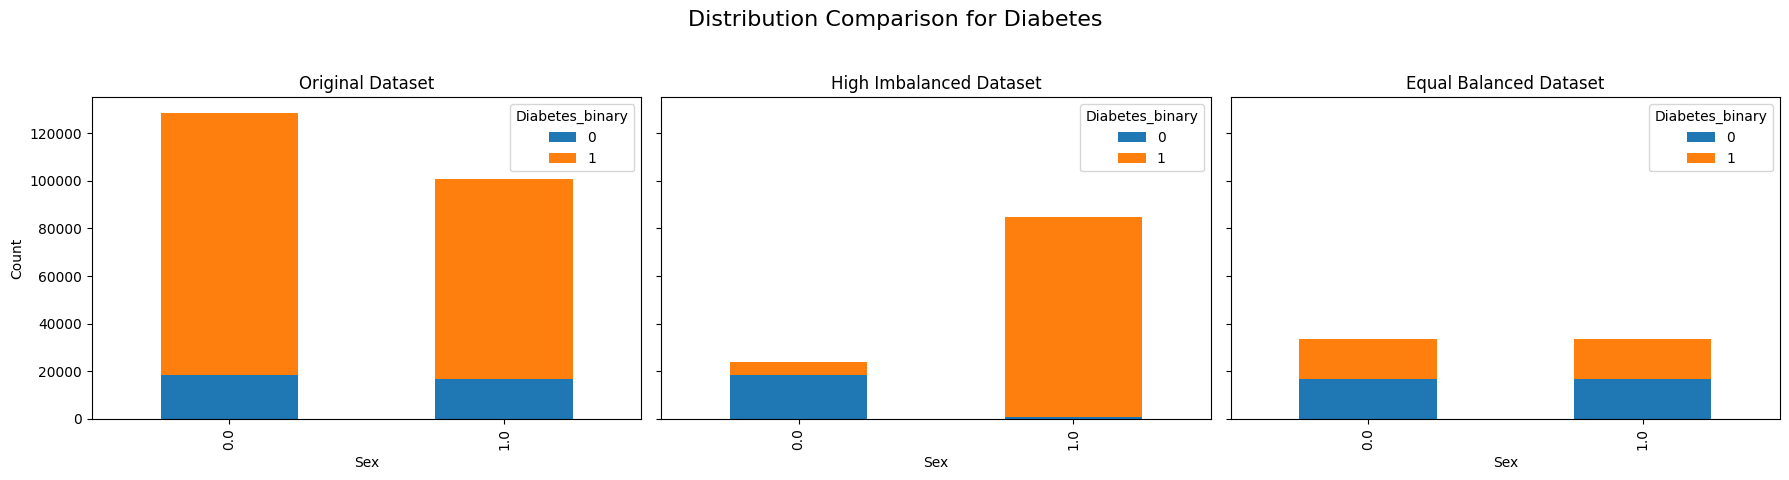

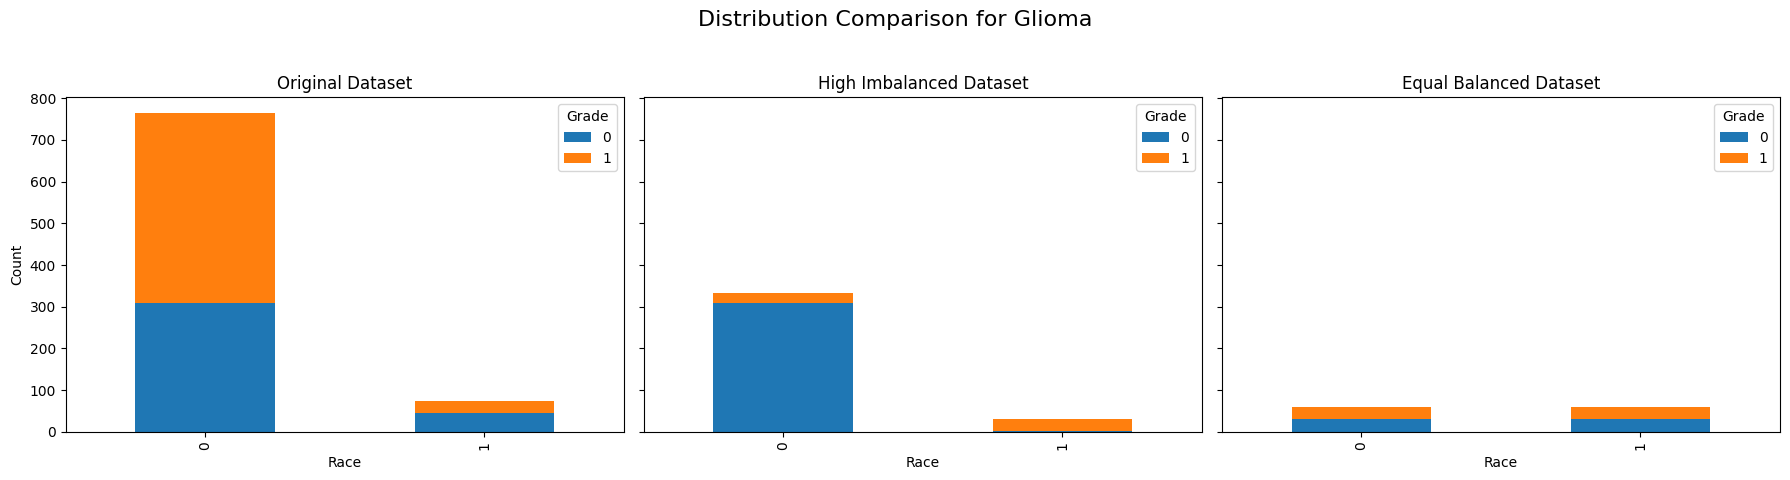

In [6]:
for name, file, target, attr_mapping in zip(dataset_names, dataset_files, dataset_targets, dataset_attr_mappings):
    protected_attr = list(attr_mapping.keys())[0]
    original_df = pd.read_csv(file)

    imbalanced_df_path = os.path.join(output_dir, f"{name.replace(' ', '_')}/high_imbalance/{name.replace(' ', '_')}_imbalanced_dataset.csv")
    balanced_df_path = os.path.join(output_dir, f"{name.replace(' ', '_')}/equal_balance/{name.replace(' ', '_')}_balanced_dataset.csv")
    
    imbalanced_df = pd.read_csv(imbalanced_df_path)
    balanced_df = pd.read_csv(balanced_df_path)
    # plot the distribution
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(f'Distribution Comparison for {name}', fontsize=16)
    axes[0].set_title('Original Dataset')
    axes[1].set_title('High Imbalanced Dataset')
    axes[2].set_title('Equal Balanced Dataset')
    for ax, df, title in zip(axes, [original_df, imbalanced_df, balanced_df], ['Original', 'High Imbalanced', 'Equal Balanced']):
        counts = df.groupby([protected_attr, target]).size().unstack(fill_value=0)
        counts.plot(kind='bar', stacked=True, ax=ax)
        ax.set_xlabel(protected_attr)
        ax.set_ylabel('Count')
        ax.legend(title=target)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt_path = os.path.join(output_dir, f"{name.replace(' ', '_')}/distribution_comparison.png")
    plt.savefig(plt_path)